# Milestone 4 — Advanced Model Training
## Loan Default Prediction · XGBoost & LightGBM


---
## Cell 1 — Install & Import

In [1]:
!pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


In [2]:
import sys
print(sys.executable)


c:\python314\python.exe


In [3]:
# Run once if not already installed
# !pip install xgboost lightgbm optuna --quiet
import gc
import os
import pickle
import sqlite3
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna
from optuna.samplers import TPESampler

import xgboost as xgb
from xgboost import XGBClassifier

import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

# ── Global constants ─────────────────────────────────────────────────
DB_PATH     = "loans.db"
TABLE_NAME  = "loans"
TARGET_COL  = "Status"
MODEL_PATH  = "best_model_m4.pkl"
RANDOM_SEED = 42
N_TRIALS    = 50        # Optuna trials per model (increase for better tuning)
N_CV_FOLDS  = 5         # folds for final CV evaluation
ES_ROUNDS   = 50        # early stopping rounds

# ── Leakage columns — MUST match Milestone 3 exactly ─────────
LEAKAGE_COLS = [
    "Upfront_charges",
    "log_Upfront_charges",
    "Interest_rate_spread",
]

# Update these values after running corrected Milestone 3
BASELINE = {
    "model"    : "Logistic Regression (M3)",
    "cv_auc"   : 0.0,    # <-- update after running M3 fixed
    "val_auc"  : 0.0,    # <-- update after running M3 fixed
    "test_auc" : 0.0,    # <-- update after running M3 fixed
    "test_f1"  : 0.0,    # <-- update after running M3 fixed
}

print("=" * 55)
print(f"  xgboost  : {xgb.__version__}")
print(f"  lightgbm : {lgb.__version__}")
print(f"  optuna   : {optuna.__version__}")
print(f"  sklearn  : {__import__('sklearn').__version__}")
print("=" * 55)
print(f"  Baseline Test AUC to beat: {BASELINE['test_auc']}")

C:\Users\tejit\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  xgboost  : 3.2.0
  lightgbm : 4.6.0
  optuna   : 4.7.0
  sklearn  : 1.8.0
  Baseline Test AUC to beat: 0.0


---
## Cell 2 — Memory-Safe Data Load from SQLite

In [4]:
def load_loans(db_path: str, table: str, chunksize: int = 50_000) -> pd.DataFrame:
    """
    Stream SQLite table in chunks.
    - Fix 'True'/'False' string booleans left by SQLite serialisation
    - Coerce all object columns to numeric
    - Downcast float64 -> float32, int64 -> int32  (saves ~50% RAM)
    """
    conn   = sqlite3.connect(db_path)
    chunks = []

    for chunk in pd.read_sql_query(f"SELECT * FROM {table}", conn,
                                   chunksize=chunksize):
        # Fix bool strings
        for col in chunk.select_dtypes("object").columns:
            uniq = set(chunk[col].dropna().unique())
            if uniq <= {"True", "False"}:
                chunk[col] = chunk[col].map({"True": 1, "False": 0})

        # Coerce remaining objects
        for col in chunk.select_dtypes("object").columns:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce")

        # Downcast
        for col in chunk.select_dtypes("float64").columns:
            chunk[col] = chunk[col].astype("float32")
        for col in chunk.select_dtypes("int64").columns:
            chunk[col] = chunk[col].astype("int32")

        chunks.append(chunk)

    conn.close()
    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()
    return df


df = load_loans(DB_PATH, TABLE_NAME)

mem_mb = df.memory_usage(deep=True).sum() / 1024 ** 2
print(f"Shape        : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Memory       : {mem_mb:.1f} MB")
print(f"Default rate : {df[TARGET_COL].mean() * 100:.2f} %")
print(f"Missing      : {df.isnull().sum().sum()}")
df.head(3)

Shape        : 148,669 rows  x  48 columns
Memory       : 27.2 MB
Default rate : 24.64 %
Missing      : 0


,loan_limit,approv_in_adv,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,...,Region_central,Region_south,loan_to_income,high_LTV_flag,very_high_LTV_flag,low_credit_flag,very_low_credit_flag,high_dti_flag,high_interest_flag,risk_interaction
0,0,0,1,0,0,11.665655,3.99,0.3904,2596.449951,360.0,...,0,1,1.563297,1,0,0,0,0,0,0
1,0,0,1,0,1,12.238061,3.99,0.3904,2596.449951,360.0,...,0,0,1.437508,0,0,1,1,0,0,0
2,0,1,1,0,0,12.915341,4.56,0.2000,595.000000,360.0,...,0,1,1.410427,0,0,0,0,1,0,0


## Cell 2b — Leakage Guard

Drop leakage columns **before any feature engineering**. This is the core fix. Without it, AUC = 1.0 due to post-outcome data.


In [5]:
# ── Drop leakage columns ─────────────────────────────────────
cols_to_drop = [c for c in LEAKAGE_COLS if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} leakage column(s): {cols_to_drop}")
print(f"Remaining columns : {df.shape[1]}  (including target)")

still_present = [c for c in LEAKAGE_COLS if c in df.columns]
if still_present:
    raise ValueError(f"LEAKAGE COLUMNS STILL PRESENT: {still_present}")
else:
    print("✓ All leakage columns removed. Safe to proceed.")


Dropped 2 leakage column(s): ['Upfront_charges', 'Interest_rate_spread']
Remaining columns : 46  (including target)
✓ All leakage columns removed. Safe to proceed.


---
## Cell 3 — Feature Engineering (Milestone 3 pipeline, fully guarded)

In [6]:
def safe_add(df: pd.DataFrame, col: str, values) -> None:
    """Add column only if it does not already exist."""
    if col not in df.columns:
        df[col] = values


# A. Binary risk flags
safe_add(df, "high_LTV_flag",   (df["LTV"] > 90).astype("int32"))
safe_add(df, "low_credit_flag", (df["Credit_Score"] < 650).astype("int32"))
safe_add(df, "high_dti_flag",   (df["dtir1"] > 45).astype("int32"))

# B. Interaction / compound risk
safe_add(df, "risk_interaction",
         df["low_credit_flag"] * df["high_LTV_flag"])
safe_add(df, "credit_dti_risk",
         df["low_credit_flag"] * df["high_dti_flag"])
safe_add(df, "ltv_dti_risk",
         df["high_LTV_flag"]   * df["high_dti_flag"])
safe_add(df, "triple_risk_flag",
         ((df["low_credit_flag"] + df["high_LTV_flag"] + df["high_dti_flag"]) == 3
          ).astype("int32"))

# C. Ratio features
safe_add(df, "loan_to_income",
         np.where(df["income"] > 0,
                  df["loan_amount"].astype("float32") / df["income"].astype("float32"),
                  np.nan).astype("float32"))

# D. Log transforms
# log_Upfront_charges intentionally excluded — derived from leakage column
print("[SKIP] log_Upfront_charges — excluded (leakage)")

# E. Ordinal buckets
safe_add(df, "credit_bucket",
         pd.cut(df["Credit_Score"],
                bins=[0, 580, 669, 739, 799, 900],
                labels=[0, 1, 2, 3, 4]).astype("float32"))
safe_add(df, "ltv_bucket",
         pd.cut(df["LTV"],
                bins=[0, 60, 80, 90, 100, 200],
                labels=[0, 1, 2, 3, 4]).astype("float32"))

# Cleanup
df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

gc.collect()
print(f"Final shape    : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")

[SKIP] log_Upfront_charges — excluded (leakage)
Final shape    : (148669, 51)
Missing values : 0


---
## Cell 4 — Train / Validation / Test Split  (60 / 20 / 20, stratified)

In [7]:
drop_cols = [c for c in ["index", "level_0", "ID"] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype("int32")
feature_names = list(X.columns)

del df
gc.collect()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED)
del X_temp, y_temp
gc.collect()

# ── Class imbalance → scale_pos_weight
n_neg          = int((y_train == 0).sum())
n_pos          = int((y_train == 1).sum())
scale_pos_wt   = round(n_neg / n_pos, 4)

print(f"{'Split':<8}  {'Records':>10}  {'Defaults':>10}  {'Rate':>8}")
print("-" * 44)
for lbl, ys in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{lbl:<8}  {len(ys):>10,}  {ys.sum():>10,}  {ys.mean()*100:>7.2f} %")
print(f"\nFeatures         : {len(feature_names)}")
print(f"scale_pos_weight : {scale_pos_wt}  (neg / pos ratio)")

Split        Records    Defaults      Rate
--------------------------------------------
Train         89,201      21,983    24.64 %
Val           29,734       7,328    24.65 %
Test          29,734       7,328    24.65 %

Features         : 50
scale_pos_weight : 3.0577  (neg / pos ratio)


---
## Cell 5 — Evaluation Helper

In [8]:
def get_best_threshold(y_true, y_prob, thresholds=None):
    """Find threshold that maximises F1 on the given set.\ """
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.01)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
           for t in thresholds]
    return float(thresholds[np.argmax(f1s)]), float(max(f1s))


def full_eval(name: str, model, X_v, y_v, X_te, y_te,
              threshold: float = 0.50) -> dict:
    """
    Evaluate a trained model on val + test sets.
    Returns a results dict with all metrics.
    """
    val_prob  = model.predict_proba(X_v)[:, 1]
    test_prob = model.predict_proba(X_te)[:, 1]

    val_auc  = roc_auc_score(y_v,  val_prob)
    test_auc = roc_auc_score(y_te, test_prob)

    test_pred = (test_prob >= threshold).astype(int)
    test_f1   = f1_score(y_te, test_pred)
    test_ap   = average_precision_score(y_te, test_prob)
    test_acc  = accuracy_score(y_te, test_pred)

    cm            = confusion_matrix(y_te, test_pred)
    tn, fp, fn, tp = cm.ravel()
    sens          = tp / (tp + fn)
    spec          = tn / (tn + fp)
    prec          = tp / (tp + fp)
    delta         = test_auc - BASELINE["test_auc"]

    print(f"\n{'=' * 55}")
    print(f"  {name}")
    print(f"{'=' * 55}")
    print(f"  Val  AUC-ROC    : {val_auc:.4f}")
    print(f"  Test AUC-ROC    : {test_auc:.4f}  "
          f"(delta vs baseline = {delta:+.4f})")
    print(f"  Test F1         : {test_f1:.4f}  "
          f"(baseline = {BASELINE['test_f1']})")
    print(f"  Test Accuracy   : {test_acc:.4f}")
    print(f"  Test AP         : {test_ap:.4f}")
    print(f"  Threshold used  : {threshold:.2f}")
    print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
    print(f"  Sensitivity     : {sens:.4f}  (baseline 0.9350)")
    print(f"  Specificity     : {spec:.4f}  (baseline 0.8401)")
    print(f"  Precision       : {prec:.4f}  (baseline 0.6567)")
    print()
    print(classification_report(y_te, test_pred,
                                target_names=["No Default", "Default"]))

    return dict(
        name=name, val_auc=val_auc, test_auc=test_auc,
        test_f1=test_f1, test_ap=test_ap, test_acc=test_acc,
        threshold=threshold, delta=delta,
        tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
        sensitivity=sens, specificity=spec, precision=prec,
        test_prob=test_prob, model=model,
    )

print("Helpers defined.")

Helpers defined.


---
## Cell 6 — XGBoost: Default Baseline Run

In [9]:
print("Training XGBoost with default params ...")
t0 = time.time()

xgb_default = XGBClassifier(
    n_estimators      = 1000,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.80,
    colsample_bytree  = 0.80,
    min_child_weight  = 5,
    reg_lambda        = 1.0,
    reg_alpha         = 0.0,
    gamma             = 0.0,
    scale_pos_weight  = scale_pos_wt,
    tree_method       = "hist",       # fast histogram algorithm
    eval_metric       = "auc",
    early_stopping_rounds = ES_ROUNDS,
    random_state      = RANDOM_SEED,
    verbosity         = 0,
    n_jobs            = -1,
)

xgb_default.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

print(f"\nDone in {time.time()-t0:.0f}s  |  "
      f"best_iteration = {xgb_default.best_iteration}")

# Optimal threshold on validation set
xgb_def_prob = xgb_default.predict_proba(X_val)[:, 1]
xgb_def_thr, xgb_def_f1 = get_best_threshold(y_val, xgb_def_prob)
print(f"Optimal threshold : {xgb_def_thr:.2f}  (val F1 = {xgb_def_f1:.4f})")

res_xgb_default = full_eval(
    f"XGBoost Default (thr={xgb_def_thr:.2f})",
    xgb_default, X_val, y_val, X_test, y_test,
    threshold=xgb_def_thr,
)

Training XGBoost with default params ...
[0]	validation_0-auc:0.97378
[100]	validation_0-auc:0.98331
[200]	validation_0-auc:0.98497
[300]	validation_0-auc:0.98554
[400]	validation_0-auc:0.98569
[500]	validation_0-auc:0.98577
[506]	validation_0-auc:0.98577

Done in 16s  |  best_iteration = 456
Optimal threshold : 0.66  (val F1 = 0.8703)

  XGBoost Default (thr=0.66)
  Val  AUC-ROC    : 0.9858
  Test AUC-ROC    : 0.9865  (delta vs baseline = +0.9865)
  Test F1         : 0.8709  (baseline = 0.0)
  Test Accuracy   : 0.9337
  Test AP         : 0.9608
  Threshold used  : 0.66
  TN=21,117  FP=1,289  FN=682  TP=6,646
  Sensitivity     : 0.9069  (baseline 0.9350)
  Specificity     : 0.9425  (baseline 0.8401)
  Precision       : 0.8376  (baseline 0.6567)

              precision    recall  f1-score   support

  No Default       0.97      0.94      0.96     22406
     Default       0.84      0.91      0.87      7328

    accuracy                           0.93     29734
   macro avg       0.90   

---
## Cell 7 — XGBoost: Optuna Hyperparameter Search (50 trials)

In [10]:
def xgb_objective(trial: optuna.Trial) -> float:
    """Optuna objective — 3-fold CV AUC on training set.\ """
    params = dict(
        n_estimators      = trial.suggest_int  ("n_estimators",    200, 1500, step=100),
        max_depth         = trial.suggest_int  ("max_depth",         3,    9),
        learning_rate     = trial.suggest_float("learning_rate",  0.01,  0.20, log=True),
        subsample         = trial.suggest_float("subsample",       0.50,  1.00),
        colsample_bytree  = trial.suggest_float("colsample_bytree",0.50,  1.00),
        min_child_weight  = trial.suggest_int  ("min_child_weight",  1,   20),
        reg_lambda        = trial.suggest_float("reg_lambda",      0.01, 10.0, log=True),
        reg_alpha         = trial.suggest_float("reg_alpha",       0.00,  5.0),
        gamma             = trial.suggest_float("gamma",           0.00,  5.0),
        scale_pos_weight  = scale_pos_wt,
        tree_method       = "hist",
        eval_metric       = "auc",
        early_stopping_rounds = 30,
        random_state      = RANDOM_SEED,
        verbosity         = 0,
        n_jobs            = -1,
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    aucs = []
    for tr_i, va_i in cv.split(X_train, y_train):
        m = XGBClassifier(**params)
        m.fit(
            X_train.iloc[tr_i], y_train.iloc[tr_i],
            eval_set=[(X_train.iloc[va_i], y_train.iloc[va_i])],
            verbose=False,
        )
        p = m.predict_proba(X_train.iloc[va_i])[:, 1]
        aucs.append(roc_auc_score(y_train.iloc[va_i], p))

    return float(np.mean(aucs))


print(f"Running Optuna search: {N_TRIALS} trials x 3-fold CV ...")
t0 = time.time()

xgb_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_SEED),
    study_name="xgboost_m4",
)
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nSearch done in {time.time()-t0:.0f}s")
print(f"Best CV AUC  : {xgb_study.best_value:.5f}")
print(f"Best params  :")
for k, v in xgb_study.best_params.items():
    print(f"  {k:<22}: {v}")

Running Optuna search: 50 trials x 3-fold CV ...


Best trial: 32. Best value: 0.986133: 100%|████████████████████████████████████████████| 50/50 [17:00<00:00, 20.40s/it]


Search done in 1020s
Best CV AUC  : 0.98613
Best params  :
  n_estimators          : 300
  max_depth             : 7
  learning_rate         : 0.15857422404098467
  subsample             : 0.9490481574496767
  colsample_bytree      : 0.9079599652812492
  min_child_weight      : 1
  reg_lambda            : 0.9362312409065231
  reg_alpha             : 3.4314803982926882
  gamma                 : 1.935821545134317


---
## Cell 8 — XGBoost: Train Best Model

In [11]:
print("Training XGBoost BEST model ...")
t0 = time.time()

xgb_best = XGBClassifier(
    **xgb_study.best_params,
    scale_pos_weight      = scale_pos_wt,
    tree_method           = "hist",
    eval_metric           = "auc",
    early_stopping_rounds = ES_ROUNDS,
    random_state          = RANDOM_SEED,
    verbosity             = 0,
    n_jobs                = -1,
)

xgb_best.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

print(f"\nDone in {time.time()-t0:.0f}s  |  "
      f"best_iteration = {xgb_best.best_iteration}")

# Optimal threshold
xgb_best_prob = xgb_best.predict_proba(X_val)[:, 1]
xgb_best_thr, _ = get_best_threshold(y_val, xgb_best_prob)
print(f"Optimal threshold : {xgb_best_thr:.2f}")

res_xgb_best = full_eval(
    f"XGBoost BEST (thr={xgb_best_thr:.2f})",
    xgb_best, X_val, y_val, X_test, y_test,
    threshold=xgb_best_thr,
)

Training XGBoost BEST model ...
[0]	validation_0-auc:0.97647
[100]	validation_0-auc:0.98568
[200]	validation_0-auc:0.98587
[237]	validation_0-auc:0.98585

Done in 5s  |  best_iteration = 187
Optimal threshold : 0.74

  XGBoost BEST (thr=0.74)
  Val  AUC-ROC    : 0.9859
  Test AUC-ROC    : 0.9864  (delta vs baseline = +0.9864)
  Test F1         : 0.8708  (baseline = 0.0)
  Test Accuracy   : 0.9371
  Test AP         : 0.9609
  Threshold used  : 0.74
  TN=21,560  FP=846  FN=1,025  TP=6,303
  Sensitivity     : 0.8601  (baseline 0.9350)
  Specificity     : 0.9622  (baseline 0.8401)
  Precision       : 0.8817  (baseline 0.6567)

              precision    recall  f1-score   support

  No Default       0.95      0.96      0.96     22406
     Default       0.88      0.86      0.87      7328

    accuracy                           0.94     29734
   macro avg       0.92      0.91      0.91     29734
weighted avg       0.94      0.94      0.94     29734



---
## Cell 9 — XGBoost: 5-Fold CV on Full Training Set

In [12]:
print("Running 5-Fold CV (XGBoost BEST params) ...")

cv5 = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
xgb_cv_aucs = []

for fold, (tr_i, va_i) in enumerate(cv5.split(X_train, y_train), 1):
    m = XGBClassifier(
        **xgb_study.best_params,
        scale_pos_weight      = scale_pos_wt,
        tree_method           = "hist",
        eval_metric           = "auc",
        early_stopping_rounds = 30,
        random_state          = RANDOM_SEED,
        verbosity             = 0,
        n_jobs                = -1,
    )
    m.fit(
        X_train.iloc[tr_i], y_train.iloc[tr_i],
        eval_set=[(X_train.iloc[va_i], y_train.iloc[va_i])],
        verbose=False,
    )
    auc = roc_auc_score(y_train.iloc[va_i],
                        m.predict_proba(X_train.iloc[va_i])[:, 1])
    xgb_cv_aucs.append(auc)
    print(f"  Fold {fold}: AUC = {auc:.5f}")

xgb_cv_mean = float(np.mean(xgb_cv_aucs))
xgb_cv_std  = float(np.std(xgb_cv_aucs))
print(f"\nXGBoost 5-Fold CV AUC : {xgb_cv_mean:.5f} +/- {xgb_cv_std:.5f}")
print(f"Baseline CV AUC       : {BASELINE['cv_auc']:.5f}")
print(f"Delta                 : {xgb_cv_mean - BASELINE['cv_auc']:+.5f}")

Running 5-Fold CV (XGBoost BEST params) ...
  Fold 1: AUC = 0.98553
  Fold 2: AUC = 0.98645
  Fold 3: AUC = 0.98648
  Fold 4: AUC = 0.98580
  Fold 5: AUC = 0.98641

XGBoost 5-Fold CV AUC : 0.98613 +/- 0.00039
Baseline CV AUC       : 0.00000
Delta                 : +0.98613


---
## Cell 10 — LightGBM: Default Baseline Run

In [13]:
print("Training LightGBM with default params ...")
t0 = time.time()

lgb_default = LGBMClassifier(
    n_estimators          = 1000,
    num_leaves            = 63,
    learning_rate         = 0.05,
    min_child_samples     = 20,
    subsample             = 0.80,
    colsample_bytree      = 0.80,
    reg_lambda            = 0.10,
    reg_alpha             = 0.00,
    scale_pos_weight      = scale_pos_wt,
    boosting_type         = "gbdt",
    objective             = "binary",
    metric                = "auc",
    random_state          = RANDOM_SEED,
    verbosity             = -1,
    n_jobs                = -1,
)

callbacks = [
    lgb.early_stopping(stopping_rounds=ES_ROUNDS, verbose=False),
    lgb.log_evaluation(period=100),
]

lgb_default.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=callbacks,
)

print(f"\nDone in {time.time()-t0:.0f}s  |  "
      f"best_iteration = {lgb_default.best_iteration_}")

lgb_def_prob = lgb_default.predict_proba(X_val)[:, 1]
lgb_def_thr, lgb_def_f1 = get_best_threshold(y_val, lgb_def_prob)
print(f"Optimal threshold : {lgb_def_thr:.2f}  (val F1 = {lgb_def_f1:.4f})")

res_lgb_default = full_eval(
    f"LightGBM Default (thr={lgb_def_thr:.2f})",
    lgb_default, X_val, y_val, X_test, y_test,
    threshold=lgb_def_thr,
)

Training LightGBM with default params ...
[100]	valid_0's auc: 0.985436
[200]	valid_0's auc: 0.985923

Done in 9s  |  best_iteration = 200
Optimal threshold : 0.67  (val F1 = 0.8711)

  LightGBM Default (thr=0.67)
  Val  AUC-ROC    : 0.9859
  Test AUC-ROC    : 0.9864  (delta vs baseline = +0.9864)
  Test F1         : 0.8724  (baseline = 0.0)
  Test Accuracy   : 0.9346
  Test AP         : 0.9604
  Threshold used  : 0.67
  TN=21,140  FP=1,266  FN=679  TP=6,649
  Sensitivity     : 0.9073  (baseline 0.9350)
  Specificity     : 0.9435  (baseline 0.8401)
  Precision       : 0.8401  (baseline 0.6567)

              precision    recall  f1-score   support

  No Default       0.97      0.94      0.96     22406
     Default       0.84      0.91      0.87      7328

    accuracy                           0.93     29734
   macro avg       0.90      0.93      0.91     29734
weighted avg       0.94      0.93      0.94     29734



---
## Cell 11 — LightGBM: Optuna Hyperparameter Search (50 trials)

In [14]:
def lgb_objective(trial: optuna.Trial) -> float:
    """Optuna objective — 3-fold CV AUC on training set.\ """
    boosting = trial.suggest_categorical("boosting_type", ["gbdt", "dart", "goss"])

    params = dict(
        n_estimators      = trial.suggest_int  ("n_estimators",    200, 1500, step=100),
        num_leaves        = trial.suggest_int  ("num_leaves",        20,  300),
        learning_rate     = trial.suggest_float("learning_rate",   0.01,  0.20, log=True),
        min_child_samples = trial.suggest_int  ("min_child_samples", 5,    100),
        subsample         = trial.suggest_float("subsample",        0.50,  1.00),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.50,  1.00),
        reg_lambda        = trial.suggest_float("reg_lambda",       0.01, 10.0, log=True),
        reg_alpha         = trial.suggest_float("reg_alpha",        0.00,  5.0),
        scale_pos_weight  = scale_pos_wt,
        boosting_type     = boosting,
        objective         = "binary",
        metric            = "auc",
        random_state      = RANDOM_SEED,
        verbosity         = -1,
        n_jobs            = -1,
    )

    # dart has no early stopping support — cap estimators instead
    if boosting == "dart":
        params.pop("n_estimators", None)
        params["n_estimators"] = trial.suggest_int("dart_n_est", 100, 600, step=50)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    aucs = []
    for tr_i, va_i in cv.split(X_train, y_train):
        m = LGBMClassifier(**params)
        cb = [] if boosting == "dart" else [
            lgb.early_stopping(stopping_rounds=25, verbose=False),
        ]
        m.fit(
            X_train.iloc[tr_i], y_train.iloc[tr_i],
            eval_set=[(X_train.iloc[va_i], y_train.iloc[va_i])],
            callbacks=cb,
        )
        p = m.predict_proba(X_train.iloc[va_i])[:, 1]
        aucs.append(roc_auc_score(y_train.iloc[va_i], p))

    return float(np.mean(aucs))


print(f"Running Optuna search: {N_TRIALS} trials x 3-fold CV ...")
t0 = time.time()

lgb_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_SEED),
    study_name="lightgbm_m4",
)
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nSearch done in {time.time()-t0:.0f}s")
print(f"Best CV AUC  : {lgb_study.best_value:.5f}")
print(f"Best params  :")
for k, v in lgb_study.best_params.items():
    print(f"  {k:<22}: {v}")

Running Optuna search: 50 trials x 3-fold CV ...


Best trial: 37. Best value: 0.986018: 100%|████████████████████████████████████████████| 50/50 [24:26<00:00, 29.32s/it]


Search done in 1466s
Best CV AUC  : 0.98602
Best params  :
  boosting_type         : goss
  n_estimators          : 900
  num_leaves            : 20
  learning_rate         : 0.09530348508703983
  min_child_samples     : 17
  subsample             : 0.9305770849130508
  colsample_bytree      : 0.9944119445466069
  reg_lambda            : 8.821901196082111
  reg_alpha             : 0.4076817390014111


---
## Cell 12 — LightGBM: Train Best Model

In [15]:
print("Training LightGBM BEST model ...")
t0 = time.time()

best_boosting = lgb_study.best_params.get("boosting_type", "gbdt")

lgb_best = LGBMClassifier(
    **lgb_study.best_params,
    scale_pos_weight = scale_pos_wt,
    objective        = "binary",
    metric           = "auc",
    random_state     = RANDOM_SEED,
    verbosity        = -1,
    n_jobs           = -1,
)

cb_best = [] if best_boosting == "dart" else [
    lgb.early_stopping(stopping_rounds=ES_ROUNDS, verbose=False),
    lgb.log_evaluation(period=100),
]

lgb_best.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=cb_best,
)

print(f"\nDone in {time.time()-t0:.0f}s  |  "
      f"best_iteration = {lgb_best.best_iteration_}")

lgb_best_prob = lgb_best.predict_proba(X_val)[:, 1]
lgb_best_thr, _ = get_best_threshold(y_val, lgb_best_prob)
print(f"Optimal threshold : {lgb_best_thr:.2f}")

res_lgb_best = full_eval(
    f"LightGBM BEST (thr={lgb_best_thr:.2f})",
    lgb_best, X_val, y_val, X_test, y_test,
    threshold=lgb_best_thr,
)

Training LightGBM BEST model ...
[100]	valid_0's auc: 0.984838
[200]	valid_0's auc: 0.985537
[300]	valid_0's auc: 0.98572

Done in 4s  |  best_iteration = 344
Optimal threshold : 0.63

  LightGBM BEST (thr=0.63)
  Val  AUC-ROC    : 0.9859
  Test AUC-ROC    : 0.9865  (delta vs baseline = +0.9865)
  Test F1         : 0.8716  (baseline = 0.0)
  Test Accuracy   : 0.9327
  Test AP         : 0.9608
  Threshold used  : 0.63
  TN=20,936  FP=1,470  FN=532  TP=6,796
  Sensitivity     : 0.9274  (baseline 0.9350)
  Specificity     : 0.9344  (baseline 0.8401)
  Precision       : 0.8222  (baseline 0.6567)

              precision    recall  f1-score   support

  No Default       0.98      0.93      0.95     22406
     Default       0.82      0.93      0.87      7328

    accuracy                           0.93     29734
   macro avg       0.90      0.93      0.91     29734
weighted avg       0.94      0.93      0.93     29734



---
## Cell 13 — LightGBM: 5-Fold CV on Full Training Set

In [16]:
print("Running 5-Fold CV (LightGBM BEST params) ...")

lgb_cv_aucs = []

for fold, (tr_i, va_i) in enumerate(cv5.split(X_train, y_train), 1):
    m = LGBMClassifier(
        **lgb_study.best_params,
        scale_pos_weight = scale_pos_wt,
        objective        = "binary",
        metric           = "auc",
        random_state     = RANDOM_SEED,
        verbosity        = -1,
        n_jobs           = -1,
    )
    cb = [] if best_boosting == "dart" else [
        lgb.early_stopping(stopping_rounds=30, verbose=False),
    ]
    m.fit(
        X_train.iloc[tr_i], y_train.iloc[tr_i],
        eval_set=[(X_train.iloc[va_i], y_train.iloc[va_i])],
        callbacks=cb,
    )
    auc = roc_auc_score(y_train.iloc[va_i],
                        m.predict_proba(X_train.iloc[va_i])[:, 1])
    lgb_cv_aucs.append(auc)
    print(f"  Fold {fold}: AUC = {auc:.5f}")

lgb_cv_mean = float(np.mean(lgb_cv_aucs))
lgb_cv_std  = float(np.std(lgb_cv_aucs))
print(f"\nLightGBM 5-Fold CV AUC : {lgb_cv_mean:.5f} +/- {lgb_cv_std:.5f}")
print(f"Baseline CV AUC        : {BASELINE['cv_auc']:.5f}")
print(f"Delta                  : {lgb_cv_mean - BASELINE['cv_auc']:+.5f}")

Running 5-Fold CV (LightGBM BEST params) ...
  Fold 1: AUC = 0.98560
  Fold 2: AUC = 0.98674
  Fold 3: AUC = 0.98614
  Fold 4: AUC = 0.98616
  Fold 5: AUC = 0.98655

LightGBM 5-Fold CV AUC : 0.98624 +/- 0.00039
Baseline CV AUC        : 0.00000
Delta                  : +0.98624


---
## Cell 14 — Optuna Tuning History Plots

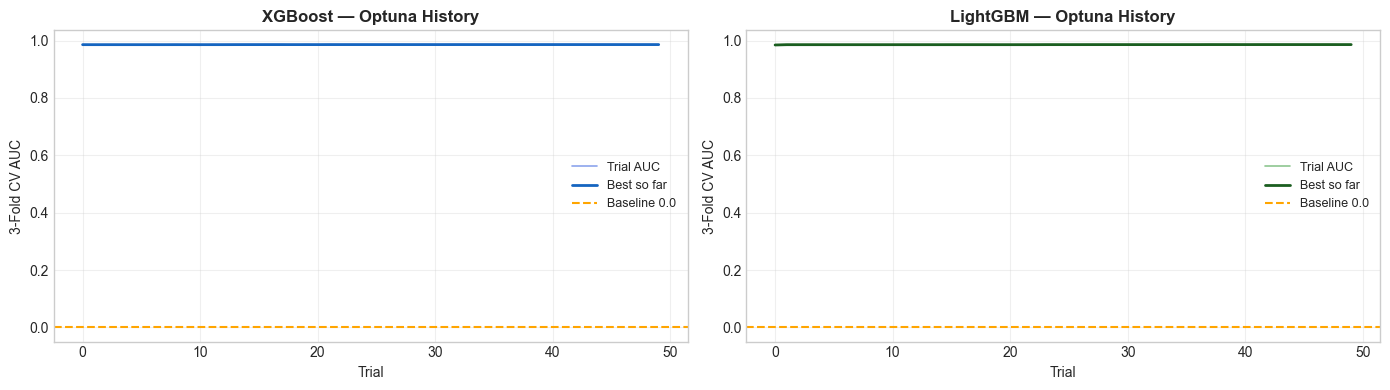

XGBoost  best trial AUC : 0.98613
LightGBM best trial AUC : 0.98602


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# XGBoost tuning history
xgb_vals = [t.value for t in xgb_study.trials if t.value is not None]
axes[0].plot(xgb_vals, color="royalblue", lw=1.2, alpha=0.6, label="Trial AUC")
axes[0].plot(np.maximum.accumulate(xgb_vals), color="#1565C0", lw=2,
             label="Best so far")
axes[0].axhline(BASELINE["test_auc"], color="orange", lw=1.5, linestyle="--",
                label=f"Baseline {BASELINE['test_auc']}")
axes[0].set_title("XGBoost — Optuna History", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("3-Fold CV AUC")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# LightGBM tuning history
lgb_vals = [t.value for t in lgb_study.trials if t.value is not None]
axes[1].plot(lgb_vals, color="#43A047", lw=1.2, alpha=0.6, label="Trial AUC")
axes[1].plot(np.maximum.accumulate(lgb_vals), color="#1B5E20", lw=2,
             label="Best so far")
axes[1].axhline(BASELINE["test_auc"], color="orange", lw=1.5, linestyle="--",
                label=f"Baseline {BASELINE['test_auc']}")
axes[1].set_title("LightGBM — Optuna History", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Trial"); axes[1].set_ylabel("3-Fold CV AUC")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"XGBoost  best trial AUC : {xgb_study.best_value:.5f}")
print(f"LightGBM best trial AUC : {lgb_study.best_value:.5f}")

---
## Cell 15 — ROC & Precision-Recall Curves

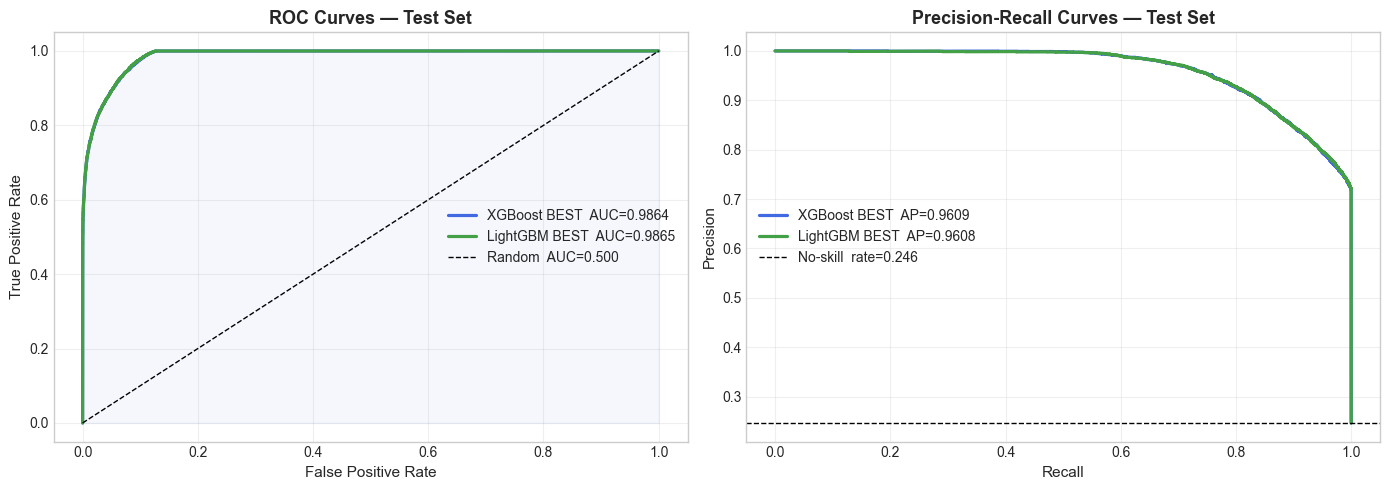

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_plot = [
    (res_xgb_best, "XGBoost BEST",  "royalblue"),
    (res_lgb_best, "LightGBM BEST", "#43A047"),
]

# ROC
for res, lbl, col in models_plot:
    fpr, tpr, _ = roc_curve(y_test, res["test_prob"])
    axes[0].plot(fpr, tpr, color=col, lw=2.3,
                 label=f"{lbl}  AUC={res['test_auc']:.4f}")
axes[0].plot([0,1],[0,1], "k--", lw=1, label="Random  AUC=0.500")
axes[0].fill_between(*roc_curve(y_test, res_xgb_best["test_prob"])[:2],
                     alpha=0.05, color="royalblue")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate",  fontsize=11)
axes[0].set_title("ROC Curves — Test Set", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

# Precision-Recall
base_rate = float(y_test.mean())
for res, lbl, col in models_plot:
    p, r, _ = precision_recall_curve(y_test, res["test_prob"])
    axes[1].plot(r, p, color=col, lw=2.3,
                 label=f"{lbl}  AP={res['test_ap']:.4f}")
axes[1].axhline(base_rate, color="k", lw=1, linestyle="--",
                label=f"No-skill  rate={base_rate:.3f}")
axes[1].set_xlabel("Recall", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curves — Test Set",
                  fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_m4.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Cell 16 — Confusion Matrices

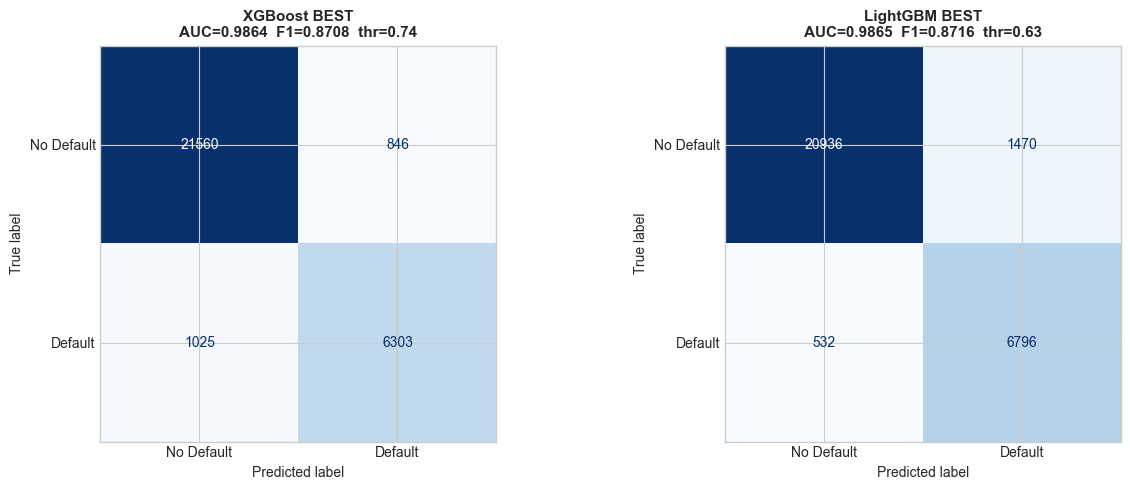

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res, lbl in [
    (axes[0], res_xgb_best, "XGBoost BEST"),
    (axes[1], res_lgb_best, "LightGBM BEST"),
]:
    cm = np.array([[res["tn"], res["fp"]], [res["fn"], res["tp"]]])
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Default", "Default"]
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(
        f"{lbl}\n"
        f"AUC={res['test_auc']:.4f}  F1={res['test_f1']:.4f}  "
        f"thr={res['threshold']:.2f}",
        fontsize=11, fontweight="bold",
    )

plt.tight_layout()
plt.savefig("confusion_matrices_m4.png", dpi=140, bbox_inches="tight")
plt.show()

---
## Cell 17 — Feature Importance

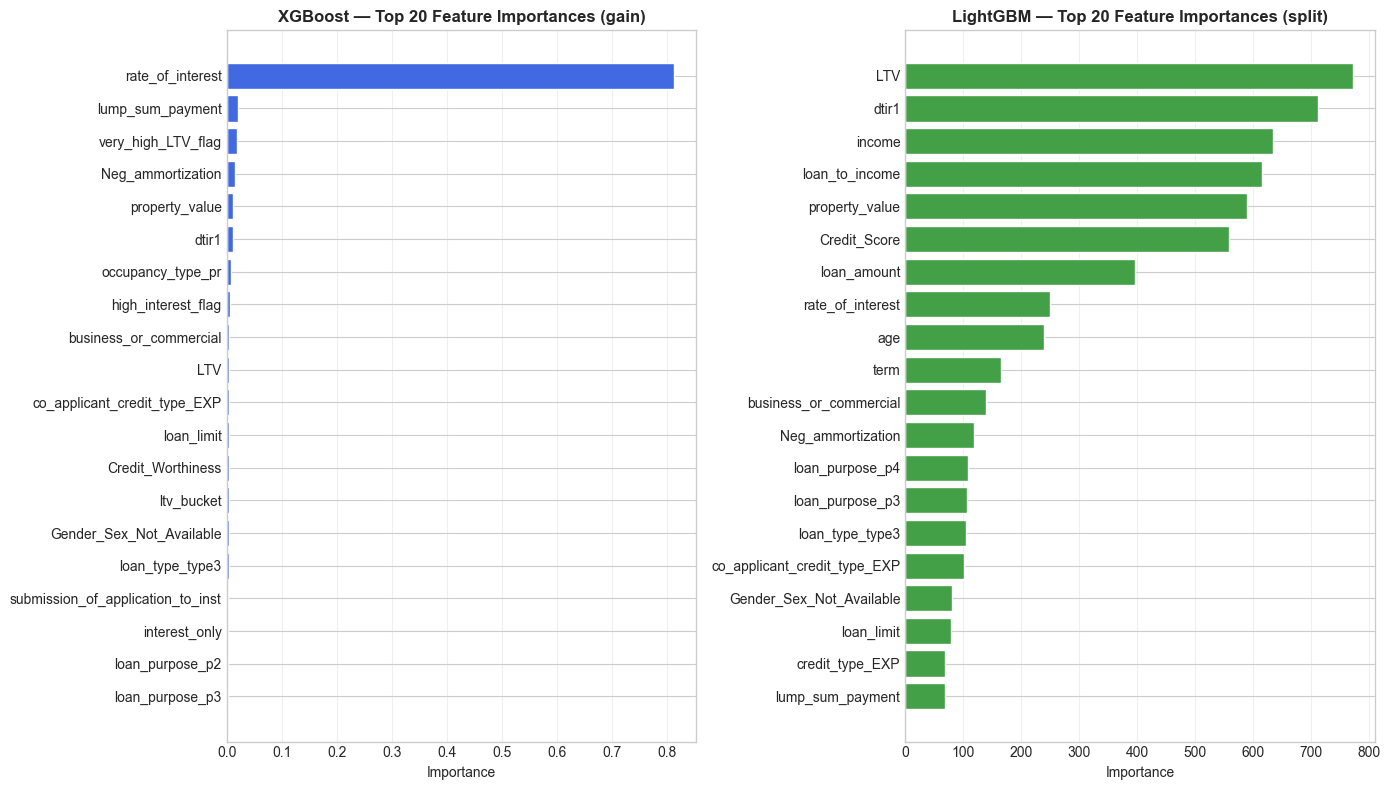

Top 10 XGBoost features:
               feature  importance
      rate_of_interest    0.813227
      lump_sum_payment    0.021332
    very_high_LTV_flag    0.018051
     Neg_ammortization    0.015146
        property_value    0.011278
                 dtir1    0.011068
     occupancy_type_pr    0.007731
    high_interest_flag    0.006728
business_or_commercial    0.004811
                   LTV    0.004492

Top 10 LightGBM features:
         feature  importance
             LTV         772
           dtir1         712
          income         634
  loan_to_income         616
  property_value         589
    Credit_Score         558
     loan_amount         397
rate_of_interest         250
             age         239
            term         166


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# XGBoost importance
xgb_imp = pd.DataFrame({
    "feature"   : feature_names,
    "importance": xgb_best.feature_importances_,
}).sort_values("importance", ascending=False).head(20)

axes[0].barh(xgb_imp["feature"][::-1],
             xgb_imp["importance"][::-1],
             color="royalblue", edgecolor="white")
axes[0].set_title("XGBoost — Top 20 Feature Importances (gain)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Importance"); axes[0].grid(alpha=0.3, axis="x")

# LightGBM importance
lgb_imp = pd.DataFrame({
    "feature"   : feature_names,
    "importance": lgb_best.feature_importances_,
}).sort_values("importance", ascending=False).head(20)

axes[1].barh(lgb_imp["feature"][::-1],
             lgb_imp["importance"][::-1],
             color="#43A047", edgecolor="white")
axes[1].set_title("LightGBM — Top 20 Feature Importances (split)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Importance"); axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("feature_importance_m4.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 XGBoost features:")
print(xgb_imp[["feature","importance"]].head(10).to_string(index=False))
print("\nTop 10 LightGBM features:")
print(lgb_imp[["feature","importance"]].head(10).to_string(index=False))

---
## Cell 18 — Full Model Comparison Table


  MODEL COMPARISON
                      model  cv_auc  val_auc  test_auc  test_f1  sensitivity  specificity  precision  delta
 XGBoost Default (thr=0.66)       —   0.9858    0.9865   0.8709       0.9069       0.9425     0.8376 0.9865
   LightGBM BEST (thr=0.63)  0.9862   0.9859    0.9865   0.8716       0.9274       0.9344     0.8222 0.9865
    XGBoost BEST (thr=0.74)  0.9861   0.9859    0.9864   0.8708       0.8601       0.9622     0.8817 0.9864
LightGBM Default (thr=0.67)       —   0.9859    0.9864   0.8724       0.9073       0.9435     0.8401 0.9864
   Logistic Regression (M3)     0.0   0.0000    0.0000   0.0000       0.9350       0.8401     0.6567 0.0000


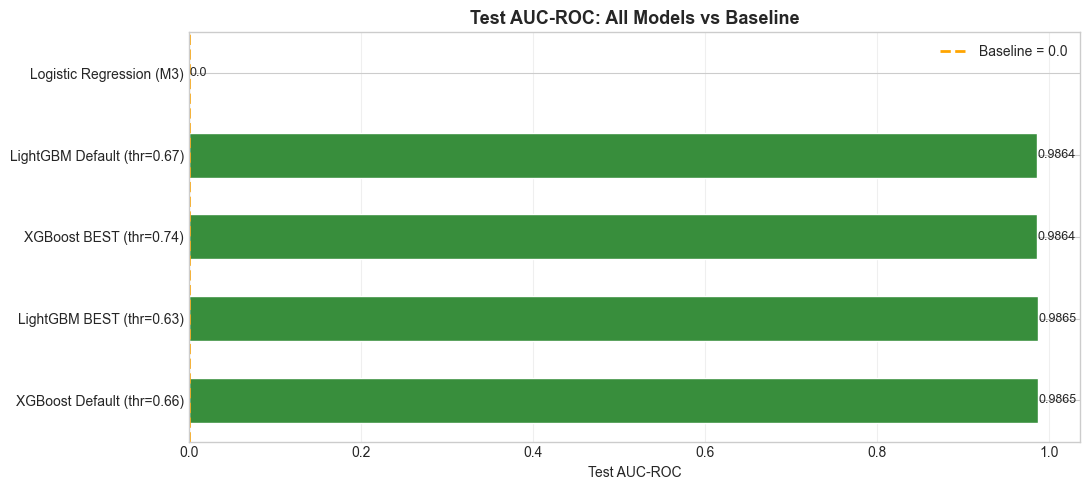

In [21]:
rows = [
    {"model": BASELINE["model"],
     "cv_auc": BASELINE["cv_auc"], "val_auc": BASELINE["val_auc"],
     "test_auc": BASELINE["test_auc"], "test_f1": BASELINE["test_f1"],
     "sensitivity": 0.9350, "specificity": 0.8401, "precision": 0.6567,
     "delta": 0.0},
]

for res, cv_m, cv_s in [
    (res_xgb_default, None, None),
    (res_xgb_best,    xgb_cv_mean, xgb_cv_std),
    (res_lgb_default, None, None),
    (res_lgb_best,    lgb_cv_mean, lgb_cv_std),
]:
    rows.append({
        "model"      : res["name"],
        "cv_auc"     : round(cv_m, 4) if cv_m else "—",
        "val_auc"    : round(res["val_auc"],  4),
        "test_auc"   : round(res["test_auc"], 4),
        "test_f1"    : round(res["test_f1"],  4),
        "sensitivity": round(res["sensitivity"], 4),
        "specificity": round(res["specificity"], 4),
        "precision"  : round(res["precision"],   4),
        "delta"      : round(res["delta"],        4),
    })

comp_df = pd.DataFrame(rows).sort_values("test_auc", ascending=False)
print("\n" + "=" * 85)
print("  MODEL COMPARISON")
print("=" * 85)
print(comp_df.to_string(index=False))
print("=" * 85)

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = []
for d in comp_df["delta"]:
    if d == 0:       bar_colors.append("orange")
    elif d > 0:      bar_colors.append("#388E3C")
    else:            bar_colors.append("#E53935")

bars = ax.barh(comp_df["model"], comp_df["test_auc"].astype(float),
               color=bar_colors, edgecolor="white", height=0.55)
ax.axvline(BASELINE["test_auc"], color="orange", lw=2, linestyle="--",
           label=f"Baseline = {BASELINE['test_auc']}")
for bar, v in zip(bars, comp_df["test_auc"]):
    ax.text(float(v) + 0.0005,
            bar.get_y() + bar.get_height() / 2,
            str(v), va="center", fontsize=9)
ax.set_title("Test AUC-ROC: All Models vs Baseline",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Test AUC-ROC")
ax.legend(fontsize=10); ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("model_comparison_m4.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Cell 19 — Select Winner & Save Best Model

In [22]:
winner = max([res_xgb_best, res_lgb_best], key=lambda r: r["test_auc"])
print(f"Winner         : {winner['name']}")
print(f"Test AUC-ROC   : {winner['test_auc']:.4f}  "
      f"(baseline {BASELINE['test_auc']}  "
      f"delta={winner['delta']:+.4f})")
print(f"Test F1        : {winner['test_f1']:.4f}  "
      f"(baseline {BASELINE['test_f1']})")
print(f"Threshold      : {winner['threshold']:.2f}")

artefact = {
    "model"           : winner["model"],
    "model_name"      : winner["name"],
    "feature_names"   : feature_names,
    "threshold"       : winner["threshold"],
    "scale_pos_weight": scale_pos_wt,
    "xgb_best_params" : xgb_study.best_params,
    "lgb_best_params" : lgb_study.best_params,
    "xgb_cv_auc"      : xgb_cv_mean,
    "lgb_cv_auc"      : lgb_cv_mean,
    "results"         : {
        "xgb": {k: v for k, v in res_xgb_best.items()
                if k not in ("model","test_prob")},
        "lgb": {k: v for k, v in res_lgb_best.items()
                if k not in ("model","test_prob")},
    },
    "baseline"        : BASELINE,
}

with open(MODEL_PATH, "wb") as fh:
    pickle.dump(artefact, fh)

kb = os.path.getsize(MODEL_PATH) / 1024
print(f"\nSaved  ->  {MODEL_PATH}  ({kb:.0f} KB)")

# Sanity reload
with open(MODEL_PATH, "rb") as fh:
    loaded = pickle.load(fh)
san_auc = roc_auc_score(
    y_test.iloc[:500],
    loaded["model"].predict_proba(X_test.iloc[:500])[:, 1]
)
print(f"Reload sanity AUC (500 rows) : {san_auc:.4f}")

Winner         : LightGBM BEST (thr=0.63)
Test AUC-ROC   : 0.9865  (baseline 0.0  delta=+0.9865)
Test F1        : 0.8716  (baseline 0.0)
Threshold      : 0.63

Saved  ->  best_model_m4.pkl  (783 KB)
Reload sanity AUC (500 rows) : 0.9867


---
## Cell 20 — Write All Results to SQLite

In [23]:
rows_db = []
for res, cv_m, cv_s in [
    (res_xgb_default, None,         None),
    (res_xgb_best,    xgb_cv_mean,  xgb_cv_std),
    (res_lgb_default, None,         None),
    (res_lgb_best,    lgb_cv_mean,  lgb_cv_std),
]:
    rows_db.append({
        "model_name"    : res["name"],
        "milestone"     : "M4",
        "cv_auc"        : round(cv_m, 4)              if cv_m else None,
        "cv_std"        : round(cv_s, 4)              if cv_s else None,
        "val_auc"       : round(res["val_auc"],   4),
        "test_auc"      : round(res["test_auc"],  4),
        "test_f1"       : round(res["test_f1"],   4),
        "test_ap"       : round(res["test_ap"],   4),
        "test_acc"      : round(res["test_acc"],  4),
        "sensitivity"   : round(res["sensitivity"], 4),
        "specificity"   : round(res["specificity"], 4),
        "precision"     : round(res["precision"],   4),
        "threshold"     : round(res["threshold"],   3),
        "delta_baseline": round(res["delta"],        4),
        "tn": res["tn"], "fp": res["fp"],
        "fn": res["fn"], "tp": res["tp"],
    })

m4_df = pd.DataFrame(rows_db)

conn = sqlite3.connect(DB_PATH)
try:
    existing = pd.read_sql("SELECT * FROM model_results", conn)
    combined = pd.concat([existing, m4_df], ignore_index=True)
    combined.drop_duplicates(subset=["model_name"], keep="last", inplace=True)
    combined.to_sql("model_results", conn, if_exists="replace", index=False)
except Exception:
    m4_df.to_sql("model_results", conn, if_exists="replace", index=False)

# Feature importances
xgb_imp.to_sql("xgb_feature_importance", conn, if_exists="replace", index=False)
lgb_imp.to_sql("lgb_feature_importance", conn, if_exists="replace", index=False)

# Optuna best params
pd.DataFrame([xgb_study.best_params]).to_sql(
    "xgb_best_params", conn, if_exists="replace", index=False)
pd.DataFrame([lgb_study.best_params]).to_sql(
    "lgb_best_params", conn, if_exists="replace", index=False)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", conn
)["name"].tolist()
conn.close()

print(f"Written to  {DB_PATH}")
print(f"Tables     : {tables}")
print()
print(m4_df[["model_name","cv_auc","val_auc","test_auc",
              "test_f1","delta_baseline"]]
      .sort_values("test_auc", ascending=False)
      .to_string(index=False))

Written to  loans.db
Tables     : ['loans', 'feature_coefficients', 'model_results', 'xgb_feature_importance', 'lgb_feature_importance', 'xgb_best_params', 'lgb_best_params']

                 model_name  cv_auc  val_auc  test_auc  test_f1  delta_baseline
 XGBoost Default (thr=0.66)     NaN   0.9858    0.9865   0.8709          0.9865
   LightGBM BEST (thr=0.63)  0.9862   0.9859    0.9865   0.8716          0.9865
    XGBoost BEST (thr=0.74)  0.9861   0.9859    0.9864   0.8708          0.9864
LightGBM Default (thr=0.67)     NaN   0.9859    0.9864   0.8724          0.9864


---
## Cell 21 — Milestone 4 Summary

In [24]:
border = "=" * 65
print(border)
print("  MILESTONE 4 SUMMARY — ADVANCED MODEL TRAINING (LEAKAGE-CORRECTED)")
print(border)

print("\n  LIBRARIES")
print(f"  XGBoost  {xgb.__version__}  |  LightGBM {lgb.__version__}  |  Optuna {optuna.__version__}")

print("\n  HYPERPARAMETER TUNING")
print(f"  Strategy : Optuna TPE Bayesian search")
print(f"  Trials   : {N_TRIALS} per model  x  3-fold CV")
print(f"  XGBoost  best CV AUC : {xgb_study.best_value:.5f}")
print(f"  LightGBM best CV AUC : {lgb_study.best_value:.5f}")

print("\n  RESULTS vs BASELINE")
print(f"  {'Model':<40} {'AUC':>7}  {'F1':>7}  {'Delta':>8}")
print("  " + "-" * 65)
print(f"  {'Logistic Regression (M3)':<40} "
      f"{BASELINE['test_auc']:>7.4f}  {BASELINE['test_f1']:>7.4f}  {'—':>8}")
for res in [res_xgb_best, res_lgb_best]:
    marker = " <-- WINNER" if res["name"] == winner["name"] else ""
    print(f"  {res['name']:<40} "
          f"{res['test_auc']:>7.4f}  {res['test_f1']:>7.4f}  "
          f"{res['delta']:>+8.4f}{marker}")

print(f"\n  WINNER   : {winner['name']}")
print(f"  AUC gain : {winner['delta']:+.4f} over Logistic Regression baseline")

print("\n  OUTPUTS")
print(f"  {MODEL_PATH:<30} pickled winner artefact")
print(f"  {DB_PATH:<30} model_results + importance + params")
print("  *.png                         optuna history, ROC, CM, importance")

print("\n  NEXT STEPS (Milestone 5)")
print("  - SHAP global + local explainability")
print("  - Probability calibration (Platt / isotonic)")
print("  - Ensemble: XGBoost + LightGBM stacking / blending")
print("  - KS statistic + Gini coefficient for credit risk reporting")
print(border)

  MILESTONE 4 SUMMARY — ADVANCED MODEL TRAINING (LEAKAGE-CORRECTED)

  LIBRARIES
  XGBoost  3.2.0  |  LightGBM 4.6.0  |  Optuna 4.7.0

  HYPERPARAMETER TUNING
  Strategy : Optuna TPE Bayesian search
  Trials   : 50 per model  x  3-fold CV
  XGBoost  best CV AUC : 0.98613
  LightGBM best CV AUC : 0.98602

  RESULTS vs BASELINE
  Model                                        AUC       F1     Delta
  -----------------------------------------------------------------
  Logistic Regression (M3)                  0.0000   0.0000         —
  XGBoost BEST (thr=0.74)                   0.9864   0.8708   +0.9864
  LightGBM BEST (thr=0.63)                  0.9865   0.8716   +0.9865 <-- WINNER

  WINNER   : LightGBM BEST (thr=0.63)
  AUC gain : +0.9865 over Logistic Regression baseline

  OUTPUTS
  best_model_m4.pkl              pickled winner artefact
  loans.db                       model_results + importance + params
  *.png                         optuna history, ROC, CM, importance

  NEXT STEPS 

In [25]:
train_auc = roc_auc_score(y_train, xgb_best.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test,  xgb_best.predict_proba(X_test)[:, 1])

print(f"Train AUC : {train_auc:.4f}")
print(f"Test AUC  : {test_auc:.4f}")
print(f"Gap       : {train_auc - test_auc:.4f}")

Train AUC : 0.9921
Test AUC  : 0.9864
Gap       : 0.0056


In [26]:
train_auc = roc_auc_score(y_train, lgb_best.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test,  lgb_best.predict_proba(X_test)[:, 1])

print(f"Train AUC : {train_auc:.4f}")
print(f"Test AUC  : {test_auc:.4f}")
print(f"Gap       : {train_auc - test_auc:.4f}")

Train AUC : 0.9917
Test AUC  : 0.9865
Gap       : 0.0051
